In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [123]:
# create datapoints (8 points are necessary for a polynomial of degree 7) 
tdata = [0.3, 0.36, 0.94, 0.96, 0.98, 1.8, 1.86, 1.98]
xdata = [0.81, -1.02, -0.05, -0.75, -1.09, -1.02, 0.08, 1.04]

# Degree of polynomial (for 8 data points, degree = 7)
deg = len(tdata) - 1
npoints = len(tdata)

# Create a slightly perturbed dataset with random noise in ±0.1 cm
xdata2 = xdata.copy()
xdata2[3] = xdata2[3] + 0.1

# Show original and perturbed
print("Original xdata: ", xdata)
print("Perturbed xdata2: ", xdata2)

Original xdata:  [0.81, -1.02, -0.05, -0.75, -1.09, -1.02, 0.08, 1.04]
Perturbed xdata2:  [0.81, -1.02, -0.05, -0.65, -1.09, -1.02, 0.08, 1.04]


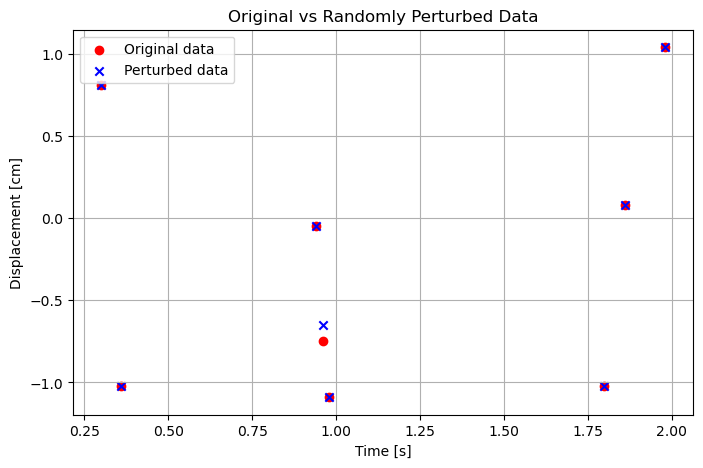

In [125]:
#Scatter plots of the data
plt.figure(figsize=(8, 5))
plt.scatter(tdata, xdata, color='red', label='Original data')
plt.scatter(tdata, xdata2, color='blue', label='Perturbed data', marker='x')
plt.xlabel("Time [s]")
plt.ylabel("Displacement [cm]")
plt.title("Original vs Randomly Perturbed Data")
plt.grid(True)
plt.legend()
plt.show()

### Why is the Vandermonde matrix square in this case?

In this exercise, we are fitting a polynomial of degree 7 to exactly 8 data points.

A polynomial of degree \( N \) has \( N+1 \) coefficients.
So here:

- Degree \( N = 7 \)
- Number of data points = 8
- Number of unknown coefficients = 8

This leads to a **square Vandermonde matrix** (8×8), and the system of equations can be solved exactly.

This is an example of **interpolation**, not approximation.  
We are forcing the polynomial to pass through **all** the given points exactly.

If we had more points than coefficients (e.g., 20 points and degree 7),  
the system would be **overdetermined**, and we would use **least squares fitting** instead.

In [128]:
def build_vandermonde(t, degree):
    """
    Build a Vandermonde matrix for a given list of points t
    and a specified polynomial degree.

    Parameters:
    t (list or array): Input x-values (e.g., time)
    degree (int): Degree of the polynomial to fit

    Returns:
    numpy.ndarray: Vandermonde matrix of shape (len(t), degree+1)

    Note:
    This function is intended for exact interpolation:
    the number of data points must equal (degree + 1).
    """
    n = len(t)
    
    if degree + 1 != n:
        raise ValueError(f"Expected {degree + 1} data points for a degree-{degree} polynomial, "
                         f"but got {n}. This falls outside the scope of exact interpolation.")

    A = np.empty((n, degree + 1))
    for i in range(n):
        for j in range(degree + 1):
            A[i, j] = t[i]**j
    return A

In [130]:
build_vandermonde(tdata, deg)

array([[1.00000000e+00, 3.00000000e-01, 9.00000000e-02, 2.70000000e-02,
        8.10000000e-03, 2.43000000e-03, 7.29000000e-04, 2.18700000e-04],
       [1.00000000e+00, 3.60000000e-01, 1.29600000e-01, 4.66560000e-02,
        1.67961600e-02, 6.04661760e-03, 2.17678234e-03, 7.83641641e-04],
       [1.00000000e+00, 9.40000000e-01, 8.83600000e-01, 8.30584000e-01,
        7.80748960e-01, 7.33904022e-01, 6.89869781e-01, 6.48477594e-01],
       [1.00000000e+00, 9.60000000e-01, 9.21600000e-01, 8.84736000e-01,
        8.49346560e-01, 8.15372698e-01, 7.82757790e-01, 7.51447478e-01],
       [1.00000000e+00, 9.80000000e-01, 9.60400000e-01, 9.41192000e-01,
        9.22368160e-01, 9.03920797e-01, 8.85842381e-01, 8.68125533e-01],
       [1.00000000e+00, 1.80000000e+00, 3.24000000e+00, 5.83200000e+00,
        1.04976000e+01, 1.88956800e+01, 3.40122240e+01, 6.12220032e+01],
       [1.00000000e+00, 1.86000000e+00, 3.45960000e+00, 6.43485600e+00,
        1.19688322e+01, 2.22620278e+01, 4.14073717e+01, 7.

In [132]:
# Step 4: Solve the linear system Vandermonde @ coeff_vector = xdata

# Degree and matrix
Vandermonde = build_vandermonde(tdata, deg)

# Solve for coefficients (more stable than using inverse)
coeff_vector = np.linalg.solve(Vandermonde, xdata)

# Display result
print("Coefficients of the interpolating polynomial:")
for i, c in enumerate(coeff_vector):
    print(f"c_{i} = {c:.6f}")

Coefficients of the interpolating polynomial:
c_0 = 1106.031740
c_1 = -10657.867491
c_2 = 39688.669004
c_3 = -73964.003437
c_4 = 75677.226217
c_5 = -43135.371335
c_6 = 12839.399689
c_7 = -1555.155329


In [134]:
def evaluate_polynomial(coeffs, t_values):
    """
    Evaluate a polynomial at given points using its coefficients.

    Parameters:
    coeffs (array): Polynomial coefficients [c0, c1, ..., cN]
    t_values (array): Points at which to evaluate the polynomial

    Returns:
    array: Values of the polynomial at the given t_values
    """
    
    # Initialize an array of zeros with the same shape as t_values 
    # Used to accumulate the polynomial result; ensure it's of type float
    result = np.zeros_like(t_values, dtype=float) 
    for i, c in enumerate(coeffs):
        result += c * t_values**i
    return result

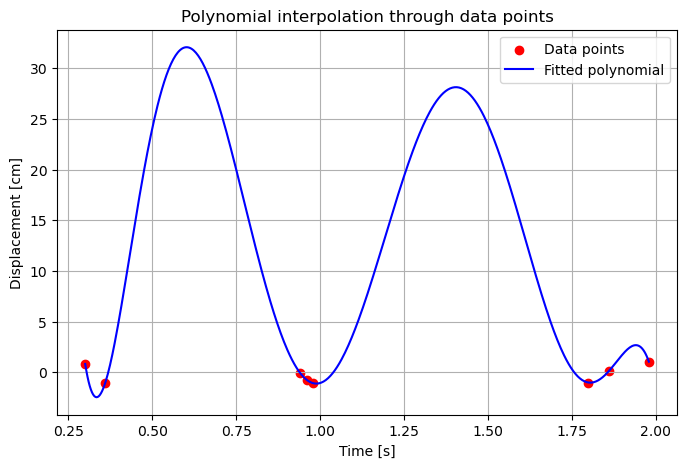

In [136]:
# Create 500 t-values from min to max of the original data
t_dense = np.linspace(min(tdata), max(tdata), 500)

# Evaluate the interpolating polynomial at these points
x_dense1 = evaluate_polynomial(coeff_vector, t_dense)

plt.figure(figsize=(8, 5))

# Original data points
plt.scatter(tdata, xdata, color='red', label='Data points')

# Fitted polynomial curve
plt.plot(t_dense, x_dense1, color='blue', label='Fitted polynomial')

# Labels and legend
plt.xlabel("Time [s]")
plt.ylabel("Displacement [cm]")
plt.title("Polynomial interpolation through data points")
plt.grid(True)
plt.legend()
plt.show()

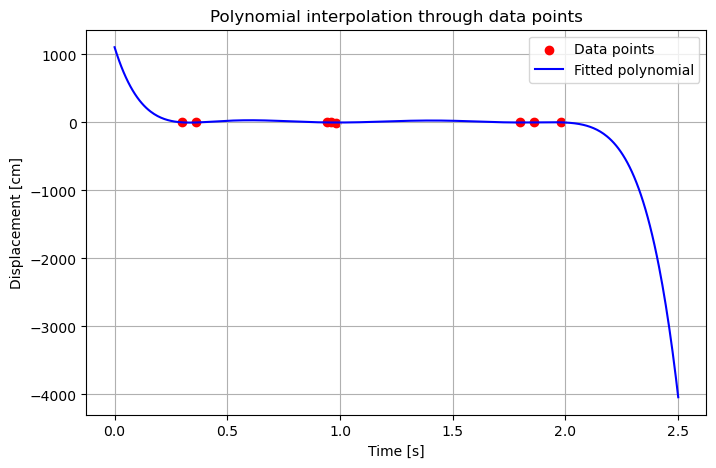

In [106]:
# Create 500 t-values from 0 to 2.5 
t_dense = np.linspace(0, 2.5, 500)

# Evaluate the interpolating polynomial at these points
x_dense2 = evaluate_polynomial(coeff_vector, t_dense)

plt.figure(figsize=(8, 5))

# Original data points
plt.scatter(tdata, xdata, color='red', label='Data points')

# Fitted polynomial curve
plt.plot(t_dense, x_dense2, color='blue', label='Fitted polynomial')

# Labels and legend
plt.xlabel("Time [s]")
plt.ylabel("Displacement [cm]")
plt.title("Polynomial interpolation through data points")
plt.grid(True)
plt.legend()
plt.show()

###  Extrapolation: When Interpolation Goes Wrong

In this plot, we extended the time range beyond the original data (e.g., from 0 to 2.5 seconds).

Even though the polynomial passes perfectly through all 8 data points within the original range,  
**it behaves wildly outside that range**.

This is a common issue when using high-degree polynomial interpolation:  
small oscillations between the data points can **explode** during extrapolation.

This instability is a known effect called **Runge's phenomenon**, and it's a key reason why:

- Polynomial interpolation should only be trusted **within the data range**
- For extrapolation, it's better to use models based on physical understanding, splines, or other techniques

 High-degree interpolation is mathematically correct, but not necessarily numerically stable or meaningful outside the known data.

In [138]:
# Build a new Vandermonde matrix (same tdata, same degree)
Vandermonde2 = build_vandermonde(tdata, deg)

# Solve new system
coeffs_perturbed = np.linalg.solve(Vandermonde2, xdata2)

# Create 500 t-values from min to max of the original data
t_dense = np.linspace(min(tdata), max(tdata), 500)

# Evaluate perturbed polynomial
x_dense_perturbed = evaluate_polynomial(coeffs_perturbed, t_dense)

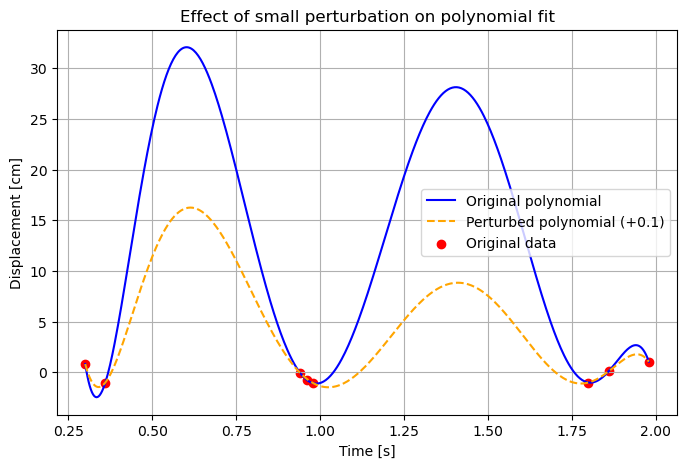

In [140]:
plt.figure(figsize=(8, 5))

plt.plot(t_dense, x_dense1, label='Original polynomial', color='blue')
plt.plot(t_dense, x_dense_perturbed, label='Perturbed polynomial (+0.1)', linestyle='--', color='orange')
plt.scatter(tdata, xdata, color='red', label='Original data')
plt.xlabel("Time [s]")
plt.ylabel("Displacement [cm]")
plt.title("Effect of small perturbation on polynomial fit")
plt.grid(True)
plt.legend()
plt.show()

### Large Change in Coefficients from Small Data Perturbation

After changing a single data point by only **+0.1 cm**, we recomputed the polynomial.

Even though the modification was minimal, the resulting coefficients changed **significantly**.

This highlights that:
- High-degree polynomial interpolation is **extremely sensitive** to small changes in data
- The entire shape of the curve — and especially its coefficients — can shift dramatically

This lack of robustness is a well-known drawback of using Vandermonde matrices in interpolation, especially with noisy or imprecise data.

In [114]:
#Compute condition number of Vandermonde matrix
cond_number = np.linalg.cond(Vandermonde)
print(f"Condition number of Vandermonde matrix: {cond_number:.2e}")

Condition number of Vandermonde matrix: 1.39e+08


### What is the Condition Number?

The **condition number** of a matrix measures how sensitive the solution of a linear system is to small changes in the input.

For a linear system:

$$
A \cdot c = x
$$

If matrix \( A \) has a large condition number:

- Small changes in \( x \) (or in the data used to build \( A \)) may lead to **very large changes in the solution \( c \)**
- The system is said to be **ill-conditioned**

---

#### In this case:

The Vandermonde matrix has a **very large condition number** (typically \( > 10^7 \), sometimes much larger).

That’s why:

- A small change (e.g. \( +0.1 \) cm in one data point) caused **huge differences** in the coefficients
- The resulting polynomial behaves very differently

Interpolation using high-degree polynomials and Vandermonde matrices is numerically unstable.

In [144]:
# Use NumPy's built-in polynomial fitting
npfit_coeffs = np.polyfit(tdata, xdata, deg) #it returns coefficients in the reverse order
x_fit_polyfit = evaluate_polynomial(npfit_coeffs[::-1], t_dense)  # reverse!

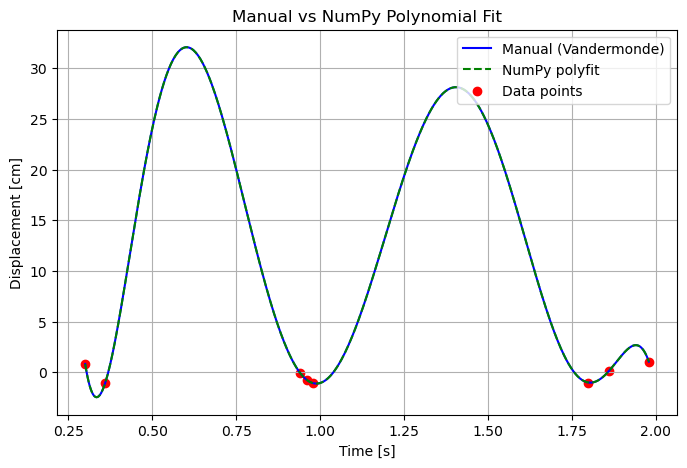

In [146]:
# Plot comparison between manual fit and NumPy polyfit
plt.figure(figsize=(8, 5))

plt.plot(t_dense, x_dense1, label='Manual (Vandermonde)', color='blue')
plt.plot(t_dense, x_fit_polyfit, label='NumPy polyfit', linestyle='--', color='green')
plt.scatter(tdata, xdata, color='red', label='Data points')

plt.xlabel("Time [s]")
plt.ylabel("Displacement [cm]")
plt.title("Manual vs NumPy Polynomial Fit")
plt.grid(True)
plt.legend()
plt.show()